In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import scqubits
from tqdm import tqdm
from IPython.display import clear_output
from functools import partial
import matplotlib

In [17]:
EJ = 3
EJ_over_EL_list = np.linspace(20,45,51)
EJ_over_EC_list = np.linspace(2,12,101)

EJ_over_EL_list,EJ_over_EC_list

(array([20. , 20.5, 21. , 21.5, 22. , 22.5, 23. , 23.5, 24. , 24.5, 25. ,
        25.5, 26. , 26.5, 27. , 27.5, 28. , 28.5, 29. , 29.5, 30. , 30.5,
        31. , 31.5, 32. , 32.5, 33. , 33.5, 34. , 34.5, 35. , 35.5, 36. ,
        36.5, 37. , 37.5, 38. , 38.5, 39. , 39.5, 40. , 40.5, 41. , 41.5,
        42. , 42.5, 43. , 43.5, 44. , 44.5, 45. ]),
 array([ 2. ,  2.1,  2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,
         3.1,  3.2,  3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,
         4.2,  4.3,  4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,
         5.3,  5.4,  5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,
         6.4,  6.5,  6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,
         7.5,  7.6,  7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,
         8.6,  8.7,  8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,
         9.7,  9.8,  9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7,
        10.8, 10.9, 11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6

In [18]:

def second_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=20):
    h = 1e-3
    derivative_old = 0.0
    print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - 2 * f(x0) + f(x0 - h)) / h**2
        print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol*np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maximum number of iterations")


def get_frequency(flux,EJ,EC,EL,i,j):
    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL =EL, cutoff = 110,flux = flux,truncated_dim=20)
    vals = qbt.eigenvals()
    return np.abs(vals[j]-vals[i])


In [19]:
upside_down_2nd_order_01 = []
upside_down_2nd_order_12 = []
conventional_2nd_order = []
for EJoverEL in EJ_over_EL_list:
    print(f"EJoverEL: {EJoverEL}")
    upside_down_2nd_order_01.append([])
    upside_down_2nd_order_12.append([])
    conventional_2nd_order.append([])
    for EJoverEC in tqdm(EJ_over_EC_list, desc = 'sweeping EJoverEC'):
        upside_down_2nd_order_01[-1].append(second_order_derivative(partial(get_frequency, EJ = EJ,EC = EJ/EJoverEC,EL=EJ/EJoverEL,i=0,j=1),x0=0))
        upside_down_2nd_order_12[-1].append(second_order_derivative(partial(get_frequency, EJ = EJ,EC = EJ/EJoverEC,EL=EJ/EJoverEL,i=1,j=2),x0=0))
        conventional_2nd_order[-1].append(second_order_derivative(partial(get_frequency, EJ = EJ,EC = EJ/EJoverEC,EL=EJ/EJoverEL,i=0,j=1),x0=0.5))
        clear_output()
        print(f"EJoverEL: {EJoverEL}")

sweeping EJoverEC: 100%|██████████| 101/101 [05:14<00:00,  3.12s/it]

EJoverEL: 45.0


In [20]:
upside_down_phi_element01 = []
upside_down_phi_element12 = []
upside_down_freq01 = []
upside_down_freq12 = []
conventional_phi_element = []
conventional_freq = []
for EJoverEL in EJ_over_EL_list:
    print(f"EJoverEL: {EJoverEL}")
    upside_down_phi_element01.append([])
    upside_down_phi_element12.append([])
    upside_down_freq01.append([])
    upside_down_freq12.append([])
    conventional_phi_element.append([])
    conventional_freq.append([])
    for EJoverEC in tqdm(EJ_over_EC_list, desc = 'sweeping EJoverEC'):
        qbt = scqubits.Fluxonium(EJ = 3,EC = 3/EJoverEC,EL = 3/EJoverEL, cutoff = 110,flux = 0,truncated_dim=20)
        tabel = qbt.matrixelement_table('phi_operator',evals_count=3)
        upside_down_phi_element01[-1].append(np.abs(tabel[1,0]))
        upside_down_phi_element12[-1].append(np.abs(tabel[2,1]))
        upside_down_freq01[-1].append(qbt.eigenvals()[1]-qbt.eigenvals()[0])
        upside_down_freq12[-1].append(qbt.eigenvals()[2]-qbt.eigenvals()[1])

        qbt = scqubits.Fluxonium(EJ = 3,EC = 3/EJoverEC,EL = 3/EJoverEL, cutoff = 110,flux = 0.5,truncated_dim=20)
        conventional_phi_element[-1].append(np.abs(qbt.matrixelement_table('phi_operator',evals_count=3)[0,1]))
        conventional_freq[-1].append(qbt.eigenvals()[1]-qbt.eigenvals()[0])

EJoverEL: 20.0


sweeping EJoverEC: 100%|██████████| 101/101 [00:33<00:00,  3.05it/s]


EJoverEL: 20.5


sweeping EJoverEC: 100%|██████████| 101/101 [00:31<00:00,  3.19it/s]


EJoverEL: 21.0


...

sweeping EJoverEC: 100%|██████████| 101/101 [00:29<00:00,  3.42it/s]


EJoverEL: 44.5


sweeping EJoverEC: 100%|██████████| 101/101 [00:38<00:00,  2.60it/s]


EJoverEL: 45.0


sweeping EJoverEC: 100%|██████████| 101/101 [00:27<00:00,  3.67it/s]


In [21]:
EJ_over_EC_array, EJ_over_EL_array = np.meshgrid(EJ_over_EC_list, EJ_over_EL_list)

upside_down_phi_element01_array = np.abs(np.array(upside_down_phi_element01))
upside_down_freq01_array = np.abs(np.array(upside_down_freq01))

upside_down_phi_element12_array = np.abs(np.array(upside_down_phi_element12))
upside_down_freq12_array = np.abs(np.array(upside_down_freq12))

conventional_phi_element_array = np.abs(np.array(conventional_phi_element))
conventional_freq_array = np.abs(np.array(conventional_freq))

upside_down_2nd_order_01_array = np.abs(np.array(upside_down_2nd_order_01))
upside_down_2nd_order_12_array = np.abs(np.array(upside_down_2nd_order_12))
conventional_2nd_order_array = np.abs(np.array(conventional_2nd_order))

import pickle
with open('data_v4_large_inductance.data', 'wb') as f:
    pickle.dump((EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array  ),f)

In [22]:
import pickle
with open('data_v4_large_inductance.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)

Text(0.5, 1.0, 'conventional_2nd_order deriv')

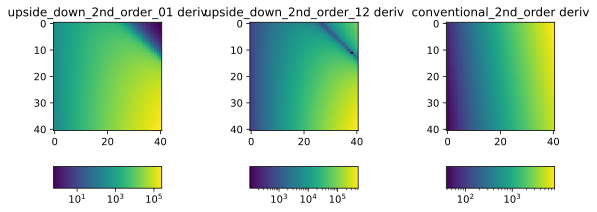

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(1,3,figsize=(10,3))
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('bottom', size='20%', pad=0.5)
im = axes[0].imshow(upside_down_2nd_order_01_array, norm=matplotlib.colors.LogNorm())
fig.colorbar(im, cax=cax, orientation='horizontal')
axes[0].set_title('upside_down_2nd_order_01 deriv')

divider = make_axes_locatable(axes[1])
cax = divider.append_axes('bottom', size='20%', pad=0.5)
im = axes[1].imshow(upside_down_2nd_order_12_array, norm=matplotlib.colors.LogNorm())
fig.colorbar(im, cax=cax, orientation='horizontal')
axes[1].set_title('upside_down_2nd_order_12 deriv')

divider = make_axes_locatable(axes[2])
cax = divider.append_axes('bottom', size='20%', pad=0.5)
im = axes[2].imshow(conventional_2nd_order_array, norm=matplotlib.colors.LogNorm())
fig.colorbar(im, cax=cax, orientation='horizontal')
axes[2].set_title('conventional_2nd_order deriv')
